In [ ]:
!pip install -U git+https://github.com/huggingface/diffusers.git

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-asnqlver
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-asnqlver
  Resolved https://github.com/huggingface/diffusers.git to commit c8c84018e0d8704e44d68ff18b634f1f61a717f6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import json
import shutil
from pathlib import Path

import pandas as pd
from src import config

print("IMAGES_512_DIR:", config.IMAGES_512_DIR)
print("CLEAN_METADATA_CSV:", config.CLEAN_METADATA_CSV)

df = pd.read_csv(config.CLEAN_METADATA_CSV)
print("Columns:", df.columns.tolist())
print("Rows:", len(df))

train_dir = config.PROCESSED_DIR / "condition_lora_dataset"
train_dir.mkdir(parents=True, exist_ok=True)

def pick(row, candidates, default=""):
    for c in candidates:
        if c in row and pd.notna(row[c]):
            val = str(row[c]).strip()
            if val:
                return val
    return default

def infer_time_weather_from_condition(cond: str):
    cond = cond.lower()
    time_val = ""
    weather_val = ""
    for t in config.TIME_LABELS:
        if t in cond:
            time_val = t
            break
    for w in config.WEATHER_LABELS:
        if w in cond:
            weather_val = w
            break
    return time_val, weather_val

records = []
seen = set()

for _, row in df.iterrows():
    filename = pick(row, ["filename", "file_name", "image", "img"])
    if not filename:
        continue
    if filename in seen:
        continue
    seen.add(filename)

    location = pick(row, ["location", "scene_id", "site", "place"], "a Penn campus building")
    time_val = pick(row, ["time", "time_of_day", "tgt_time"], "")
    weather_val = pick(row, ["weather", "tgt_weather"], "")
    condition = pick(row, ["condition", "tgt_condition", "src_condition"], "")

    if not time_val or not weather_val:
        t2, w2 = infer_time_weather_from_condition(condition)
        if not time_val:
            time_val = t2
        if not weather_val:
            weather_val = w2

    if not time_val:
        time_val = "day"
    if not weather_val:
        weather_val = "cloudy"

    src_path = config.IMAGES_512_DIR / filename
    if not src_path.exists():
        continue

    dst_path = train_dir / filename
    if not dst_path.exists():
        shutil.copy2(src_path, dst_path)

    caption = (
        f"a realistic photo of {location} on Penn campus, "
        f"at {time_val}, with {weather_val} weather, "
        f"campus architecture, photorealistic"
    )

    records.append({
        "file_name": filename,
        "text": caption
    })

meta_path = train_dir / "metadata.jsonl"
with open(meta_path, "w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r) + "\n")

print("Training folder:", train_dir)
print("metadata.jsonl:", meta_path)
print("Num training images:", len(records))

for r in records[:5]:
    print(r)

IMAGES_512_DIR: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/Data/processed/images_512
CLEAN_METADATA_CSV: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/Data/processed/metadata_clean.csv
Columns: ['filename', 'location', 'viewpoint', 'scene_id', 'time_of_day', 'weather', 'condition', 'collector']
Rows: 130
Training folder: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/Data/processed/condition_lora_dataset
metadata.jsonl: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/Data/processed/condition_lora_dataset/metadata.jsonl
Num training images: 105
{'file_name': 'collegehall_cloudy_day_front_facing_right.jpg', 'text': 'a realistic photo of College Hall on Penn campus, at day, with cloudy weather, campus architecture, photorealistic'}
{'file_name': 'collegehall_cloudy_day

In [ ]:
!mkdir -p tools
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py -O tools/train_text_to_image_lora.py
!ls tools

train_text_to_image_lora.py


In [ ]:
from src import config
condition_lora_out = config.CHECKPOINTS_DIR / "condition_lora"
condition_lora_out.mkdir(parents=True, exist_ok=True)
print(condition_lora_out)

/content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/checkpoints/condition_lora


In [ ]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
!python tools/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="{train_dir}" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --max_train_steps=1200 \
  --checkpointing_steps=300 \
  --mixed_precision="fp16" \
  --rank=16 \
  --validation_prompt="a realistic photo of collegehall on Penn campus, at night, with clear weather, campus architecture, photorealistic" \
  --validation_epochs=999999 \
  --output_dir="{condition_lora_out}"

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
04/20/2026 07:04:26 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
04/20/2026 07:04:2

In [ ]:
import os
from src import config

lora_dir = config.CHECKPOINTS_DIR / "condition_lora"
print("Files:", os.listdir(lora_dir))

Files: ['logs', 'checkpoint-300', 'checkpoint-600', 'checkpoint-900', 'checkpoint-1200', 'pytorch_lora_weights.safetensors']


In [ ]:
from pathlib import Path

inf_path = Path(project_path) / "src/models/inference.py"
code = inf_path.read_text(encoding="utf-8")

new_class = '''
class SDConditionLoRAImg2Img(Pipeline):
    name = "sd_condition_lora_img2img"

    def __init__(self, lora_path: str, strength: float = 0.55, device: str | None = None):
        from diffusers import StableDiffusionImg2ImgPipeline, UniPCMultistepScheduler
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        dtype = torch.float16 if self.device == "cuda" else torch.float32
        self.pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
            config.SD_MODEL_ID, torch_dtype=dtype, safety_checker=None,
        ).to(self.device)
        self.pipe.scheduler = UniPCMultistepScheduler.from_config(self.pipe.scheduler.config)
        from peft import PeftModel
        self.pipe.unet = PeftModel.from_pretrained(self.pipe.unet, lora_path)
        self.strength = strength

    def generate(self, source, location, time_of_day, weather, seed=42):
        src = source.convert("RGB").resize((config.IMAGE_SIZE, config.IMAGE_SIZE), Image.LANCZOS)
        prompt = build_prompt(location, time_of_day, weather)
        g = torch.Generator(self.device).manual_seed(seed)
        out = self.pipe(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            image=src,
            strength=self.strength,
            num_inference_steps=config.NUM_INFERENCE_STEPS,
            guidance_scale=config.GUIDANCE_SCALE,
            generator=g,
        ).images[0]
        return InferenceResult(image=out)
'''

if "class SDConditionLoRAImg2Img(Pipeline):" not in code:
    marker = "# ---------- 4. LoRA-only (img2img, no ControlNet) — ablation to isolate LoRA ----------"
    code = code.replace(marker, new_class + "\n\n" + marker)

old = '''    if system == "sd_lora":
        if not lora_path:
            raise ValueError("sd_lora requires --lora-path")
        return SDLoRAOnly(lora_path=lora_path)
    raise ValueError(f"unknown system: {system}")'''

new = '''    if system == "sd_lora":
        if not lora_path:
            raise ValueError("sd_lora requires --lora-path")
        return SDLoRAOnly(lora_path=lora_path)
    if system == "sd_condition_lora":
        if not lora_path:
            raise ValueError("sd_condition_lora requires --lora-path")
        return SDConditionLoRAImg2Img(lora_path=lora_path)
    raise ValueError(f"unknown system: {system}")'''

code = code.replace(old, new)

inf_path.write_text(code, encoding="utf-8")
print("Patched:", inf_path)

Patched: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/src/models/inference.py


In [ ]:
abl_path = Path(project_path) / "src/eval/ablate.py"
code = abl_path.read_text(encoding="utf-8")

code = code.replace(
    'choices=["ip2p", "sd_cn", "sd_cn_lora", "sd_lora"]',
    'choices=["ip2p", "sd_cn", "sd_cn_lora", "sd_lora", "sd_condition_lora"]'
)

code = code.replace(
    '''{"ip2p": "ip2p", "sd_cn": "sd_controlnet",
                           "sd_cn_lora": "sd_controlnet_lora",
                           "sd_lora": "sd_lora_img2img"}''',
    '''{"ip2p": "ip2p", "sd_cn": "sd_controlnet",
                           "sd_cn_lora": "sd_controlnet_lora",
                           "sd_lora": "sd_lora_img2img",
                           "sd_condition_lora": "sd_condition_lora_img2img"}'''
)

abl_path.write_text(code, encoding="utf-8")
print("Patched:", abl_path)

Patched: /content/drive/MyDrive/5190 S26 Final Project/Trained Model/MT's Testing Model/StableDiffusionProject/src/eval/ablate.py


In [ ]:
from pathlib import Path

abl_path = Path(project_path) / "src/eval/ablate.py"
code = abl_path.read_text(encoding="utf-8")

code = code.replace(
    'choices=["ip2p", "sd_cn", "sd_cn_lora", "sd_lora", "sd_condition_controlnet"]',
    'choices=["ip2p", "sd_cn", "sd_cn_lora", "sd_lora", "sd_condition_controlnet", "sd_condition_lora"]'
)

code = code.replace(
    '"sd_condition_controlnet": "sd_condition_controlnet"}',
    '"sd_condition_controlnet": "sd_condition_controlnet", "sd_condition_lora": "sd_condition_lora_img2img"}'
)

abl_path.write_text(code, encoding="utf-8")
print(" ablate.py updated")

 ablate.py updated


In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
!python -m src.eval.ablate --systems sd_condition_lora --lora-path "{condition_lora_out}" --limit 3

[ablate] 56 val pairs, running systems: ['sd_condition_lora']
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights: 100% 196/196 [00:00<00:00, 1240.35it/s]
CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-------------------------------

In [ ]:
!python -m src.eval.ablate --systems sd_condition_lora --lora-path "{condition_lora_out}"

[ablate] 56 val pairs, running systems: ['sd_condition_lora']
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:  50% 3/6 [00:09<00:11,  3.75s/it]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights:   1% 2/196 [00:00<00:22,  8.74it/s]
Loading weights:  37% 72/196 [00:00<00:00, 260.60it/s]
Loading weights:  69% 136/196 [00:00<00:00, 388.93it/s]
Loading weights: 100% 196/196 [00:00<00:00, 357.22it/s]
CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--

In [ ]:
import pandas as pd
from src import config

df = pd.read_csv(config.OUTPUTS_DIR / "results_summary.csv")
df[df["system"] == "sd_condition_lora_img2img"]

,system,n,lpips_mean,ssim_mean,psnr_mean,time_acc,weather_acc,joint_acc
0,sd_condition_lora_img2img,44,0.662957,0.114471,9.322014,0.5,0.386364,0.295455


Num outputs: 20


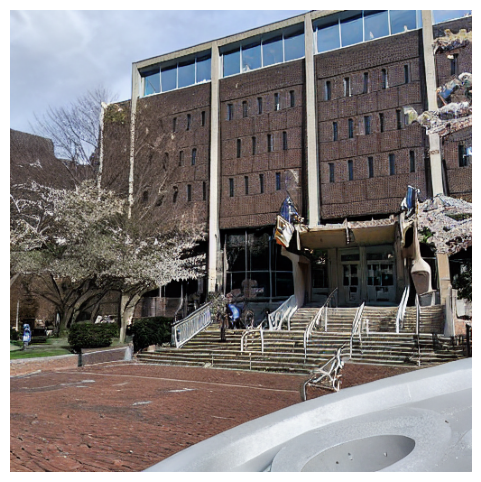

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from src import config

out_dir = config.OUTPUTS_DIR / "sd_condition_lora_img2img"
files = list(out_dir.glob("*.png"))

print("Num outputs:", len(files))
img = Image.open(files[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()